In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# Load & clean data (same as EDA notebook)
df = pd.read_csv('../data/kidney_disease.csv')
df.columns = df.columns.str.strip()
df.replace({'?': np.nan, '\t?': np.nan}, inplace=True)
df['classification'] = df['classification'].str.strip().replace({'ckd\t': 'ckd'})

print("Ready!", df.shape)

Ready! (400, 26)


In [3]:
# Correct column names from YOUR dataset
num_cols = ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']
cat_cols = ['rbc', 'pc', 'pcc', 'ba', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']

# Fix numeric columns (new pandas syntax, no inplace)
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

# Fix categorical columns
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace('nan', np.nan)
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum().sum(), "total remaining")


Missing values after cleaning:
0 total remaining


In [4]:
# Encode categoricals
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Encode target
df['classification'] = (df['classification'].str.strip() == 'ckd').astype(int)

# Drop id column (useless for prediction)
X = df.drop(['classification', 'id'], axis=1)
y = df['classification']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Results
print(classification_report(y_test, rf.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        52

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [5]:
joblib.dump(rf, '../model/model.pkl')
print("Model saved!")

Model saved!


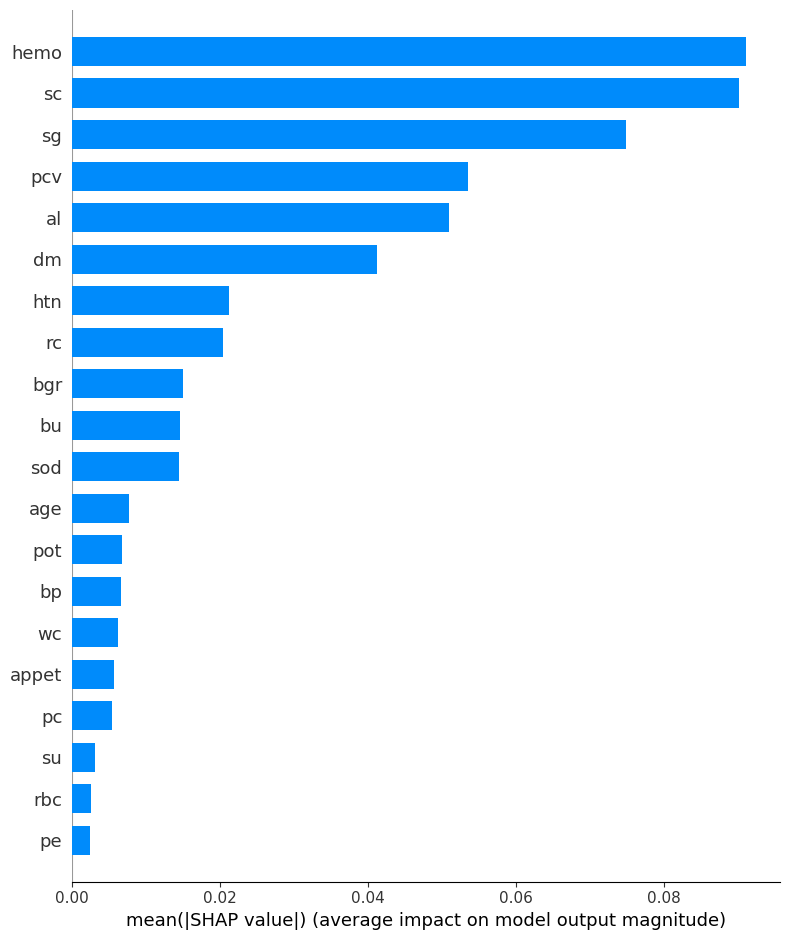

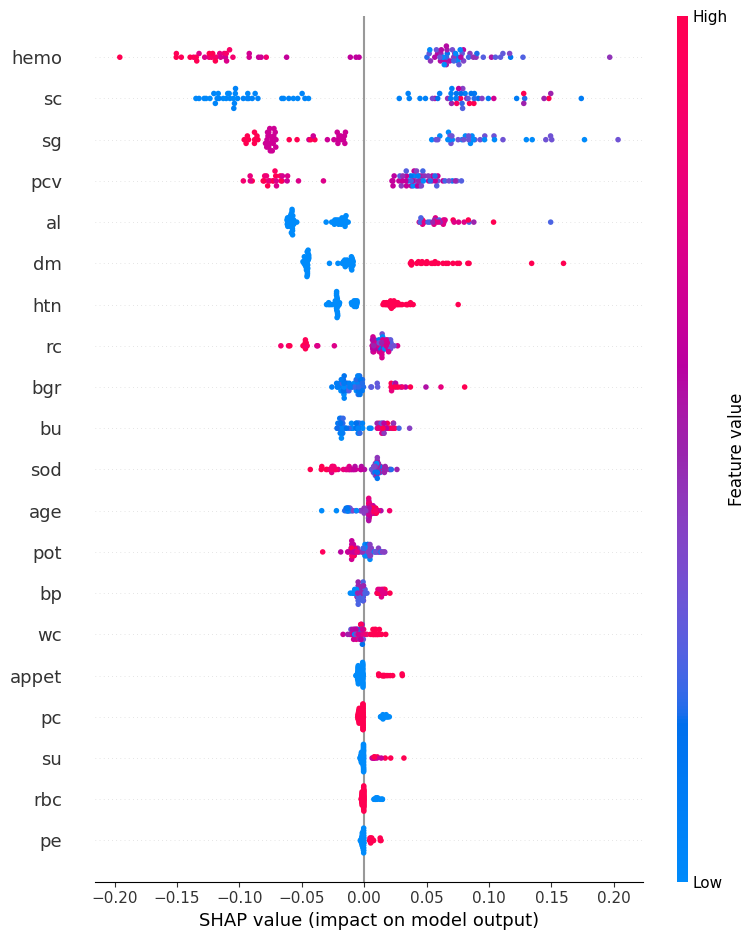

In [6]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Plot 1 — Feature importance (which features matter most)
plt.figure()
shap.summary_plot(shap_values[:,:,1], X_test, plot_type="bar", show=True)

# Plot 2 — Detailed impact (direction + magnitude)
shap.summary_plot(shap_values[:,:,1], X_test, show=True)